# FGBuster and Furax Imports for Component Separation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo/your-notebook.ipynb)


In [9]:
# FGBUSTER IMPORTS
import healpy as hp
import pysm3

from fgbuster import (CMB, Dust, Synchrotron, 
                      basic_comp_sep, MixingMatrix,
                      get_observation, get_instrument)
from fgbuster.visualization import corner_norm

# FURAX IMPORTS
import jax
import jaxopt
import jax.numpy as jnp
from jax import ShapeDtypeStruct

from furax._base.blocks import BlockDiagonalOperator, BlockRowOperator
from furax._base.core import HomothetyOperator, IdentityOperator
from furax.landscapes import StokesPyTree, ValidStokesType, HealpixLandscape
from furax.tree import as_structure
from furax.operators.sed import CMBOperator, DustOperator, SynchrotronOperator
import operator
from math import prod
import numpy as np

## Mixed Sky Maps Creation Using PySM

In this section, we create simulated sky maps using the `PySM` library with specified parameters for each astrophysical component. Key elements:

- **NSIDE**: Sets the HEALPix resolution, determining the number of pixels in the sky map.
- **Reference Frequencies**:
  - **Dust** at 150 GHz
  - **Synchrotron** at 20 GHz
- **Instrument Configuration**: Using the `LiteBIRD` instrument model to simulate observed frequency maps.

This setup provides the mixed sky maps required for component separation, with the shape of the output maps indicated for verification.


In [10]:
nside = 32
npixel = nside ** 2 * 12
dust_nu0 = 150.
synchrotron_nu0 = 20.
stokes_type: ValidStokesType = 'IQU'
instrument = get_instrument('LiteBIRD')
freq_maps = get_observation(instrument, 'c1d0s0', nside=nside)
freq_maps.shape

(15, 3, 12288)

Furax expects a `StokesPyTree` object as input, so we convert the frequency maps to the correct format, so we transform the `freq_maps` into a `StokesPyTree` object to make it compatible with Furax.

__Note__: Although Furax includes its own functions to create sky maps from PySM, we use `fgbuster` here to ensure that both methods receive identical inputs for comparison.


In [11]:
d = StokesPyTree.from_stokes(I=freq_maps[:,0,:], Q=freq_maps[:,1,:], U=freq_maps[:,2,:])
structure = HealpixLandscape(nside, stokes_type).structure
d.structure

StokesIQUPyTree(i=ShapeDtypeStruct(shape=(15, 12288), dtype=float64), q=ShapeDtypeStruct(shape=(15, 12288), dtype=float64), u=ShapeDtypeStruct(shape=(15, 12288), dtype=float64))

In [13]:
components = [CMB(), Dust(dust_nu0), Synchrotron(synchrotron_nu0)]

## Create the Mixing Matrix Operator

In this section, we define the `make_mixing_matrix_operator` function, which builds the mixing matrix operator `A` for the component separation model. Each operator represents a component (CMB, dust, or synchrotron) and handles its respective spectral energy distribution (SED) computation.

- **SED Computation**: Each operator (CMB, Dust, and Synchrotron) computes the SEDs and applies it to an input of shape `(npixels,)` for each Stokes parameter. The output shape for each Stokes parameter is `(n_freq,npixels)` , representing the SED evaluated at each frequency.

- **Operator `A`**: The operator `A` computes $A(s)$, where it evaluates the SEDs and performs matrix multiplication with the input sky matrix. This allows for operations like $A^T d$ (where $d$ represents the observed data) simply by calling `A.T(d)`.



In [ ]:
nu = instrument['frequency'].values

def make_mixing_matrix_operator(params, nu, in_structure):
    cmb = CMBOperator(nu, in_structure=in_structure)
    dust = DustOperator(
        nu,
        frequency0=dust_nu0,
        temperature=params['temp_dust'],
        beta=params['beta_dust'],
        in_structure=in_structure,
    )
    synchrotron = SynchrotronOperator(nu,
                                      frequency0=synchrotron_nu0,
                                      beta_pl=params['beta_pl'],
                                      in_structure=in_structure)
    sed = BlockDiagonalOperator({
        'cmb': cmb,
        'dust': dust,
        'synchrotron': synchrotron
    })
    integ = BlockRowOperator({
        component:
        IdentityOperator(sed.blocks[component].out_structure())
        for component in sed.blocks
    })
    return (integ @ sed).reduce()

## Defining the Likelihood Function for Component Separation

In this cell, we define the `negative_log_prob` function, which calculates the negative log-likelihood of observing the given data `d` based on the model parameters.

The likelihood function is based on a quadratic form that includes the mixing matrix `A`, inverse noise covariance `N^{-1}`, and observed data `d`. The key term in the likelihood is:

$$
\left(A^T N^{-1} d\right)^T \left(A^T N^{-1} A\right)^{-1} \left(A^T N^{-1} d\right)
$$

### Explanation of Each Term

1. **$A$**: The mixing matrix operator, which maps the component space to the observed frequency space.
2. **$N^{-1}$**: The inverse of the noise covariance matrix, represented by `invN` in the code.
3. **$d$**: The observed data, which is structured as a `StokesPyTree` in Furax.

### Implementation Details

- **Transposing and Applying `A`**: `A.T(d)` applies the transpose of `A` to `d`, equivalent to the term $A^T d$.
- **Computing the Likelihood**: The quadratic form is computed by applying $A^T N^{-1} d$, inverting $A^T N^{-1} A$, and performing matrix multiplications to evaluate the likelihood.
- **Negative Log-Likelihood**: The final output of `negative_log_prob` is the negative of this log-likelihood value, allowing us to use it as a loss function for optimization.


In [15]:
invN = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)
DND = invN(d) @ d

in_structure = HealpixLandscape(nside, stokes_type).structure
best_params = {'temp_dust': 20., 'beta_dust': 1.54, 'beta_pl': -3.0}


@jax.jit
def negative_log_prob(params, d):
    A = make_mixing_matrix_operator(params, nu, in_structure=in_structure)

    x = (A.T @ invN)(d)
    l = jax.tree.map(lambda a, b: a @ b, x, (A.T @ invN @ A).I(x))
    summed_log_prob = jax.tree.reduce(operator.add, l)

    return -summed_log_prob 

Evaluate the performance of the likelihood

In [16]:
print(f"Performance of the nll evaluation")
negative_log_prob(best_params, d).block_until_ready()
%timeit negative_log_prob(best_params, d).block_until_ready()
print(f"Performance of the nll grad evaluation")
jax.grad(negative_log_prob)(best_params, d)['beta_pl'].block_until_ready()
%timeit jax.grad(negative_log_prob)(best_params, d)['beta_pl'].block_until_ready()

6.44 ms ± 464 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Check for Correctness

In this cell, we perform a basic correctness check by comparing the gradients of the negative log-likelihood at two sets of parameters:

1. **Wrong Parameters**: A set of parameters obtained by adding random noise to `best_params`.
2. **Correct Parameters**: The original `best_params`.

By calculating and comparing the gradient magnitudes (using the `max` reduction), we can verify that the gradient at the correct parameters is smaller, indicating proximity to an optimal or near-optimal point.


In [18]:
wrong_params = jax.tree.map(lambda x: x + jax.random.normal(jax.random.PRNGKey(0)), best_params)
print(f"Wrong parameters grad {jax.tree.reduce(max , jax.grad(negative_log_prob)(wrong_params, d))}")
print(f"Correct parameters grad {jax.tree.reduce(max , jax.grad(negative_log_prob)(best_params, d))}")

Wrong parameters grad -1118221116.631031
Correct parameters grad 154.78900908121477


# Validating Against FGBuster: The `c1d0s0` Model

In this section, we validate our custom implementation of the likelihood model by comparing it to the `c1d0s0` model from `fgbuster`. By aligning our results with FGBuster’s well-established component separation model, we ensure that our setup and computations are consistent and reliable.


### Initial Validation: Using `best_params` as the Starting Point

We begin the validation process by setting `best_params` as the initial point for both our custom implementation and FGBuster’s `c1d0s0` model. This allows us to directly compare the outputs and confirm that the models produce similar results when initialized wit


In [19]:
components[1]._set_default_of_free_symbols(beta_d=1.54,temp=20.)
components[2]._set_default_of_free_symbols(beta_pl=-3.0)

result = basic_comp_sep(components, instrument, freq_maps)
print(result.params)
print(result.x)

['Dust.beta_d', 'Dust.temp', 'Synchrotron.beta_pl']
[ 1.54 20.   -3.  ]


In [20]:
best_params = {'temp_dust': 20., 'beta_dust': 1.54, 'beta_pl': -3.0}

solver = jaxopt.ScipyMinimize(fun=negative_log_prob, method='TNC',maxiter=1000 , jit=True ,tol=1e-10)
result = solver.run(best_params, d)
result.params

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


{'beta_dust': Array(1.54, dtype=float64),
 'beta_pl': Array(-3.00000063, dtype=float64),
 'temp_dust': Array(19.99999993, dtype=float64)}

## Validation with Incorrect Parameter: Setting `beta_dust` to a Wrong Value

In [21]:
components[1]._set_default_of_free_symbols(beta_d=2.54,temp=20.)
components[2]._set_default_of_free_symbols(beta_pl=-3.0)

result = basic_comp_sep(components, instrument, freq_maps)
print(result.params)
print(result.x)

<lambdifygenerated-20>:2: RuntimeWarning: overflow encountered in power
  return 568.8620443215493*(0.05*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*numpy.expm1(0.3521734047599502)**2)
<lambdifygenerated-20>:2: RuntimeWarning: overflow encountered in power
  return 568.8620443215493*(0.05*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*numpy.expm1(0.3521734047599502)**2)
<lambdifygenerated-21>:2: RuntimeWarning: overflow encountered in power
  return 568.8620443215493*(0.05*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)*log(0.05*nu)/(nu**2*numpy.expm1(0.3521734047599502)**2)


SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL = -inf
SVD of A failed -> logL = -inf


<lambdifygenerated-20>:2: RuntimeWarning: overflow encountered in multiply
  return 568.8620443215493*(0.05*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*numpy.expm1(0.3521734047599502)**2)


SVD of A failed -> logL = -inf
SVD of A failed -> logL = -inf
SVD of A failed -> logL = -inf
['Dust.beta_d', 'Dust.temp', 'Synchrotron.beta_pl']
[ 1.53194524 19.97377854 -2.9430962 ]


In [22]:
params = {'temp_dust': 20., 'beta_dust': 2.54, 'beta_pl': -3.0}

solver = jaxopt.ScipyMinimize(fun=negative_log_prob, method='TNC',maxiter=1000 , jit=True ,tol=1e-10)
result = solver.run(params, d)
result.params

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


{'beta_dust': Array(1.53999989, dtype=float64),
 'beta_pl': Array(-3.00000246, dtype=float64),
 'temp_dust': Array(20.00000439, dtype=float64)}

## Setting `beta_dust` and `beta_pl` to Incorrect Values


In [23]:
components[1]._set_default_of_free_symbols(beta_d=2.54,temp=20.)
components[2]._set_default_of_free_symbols(beta_pl=-6.0)

result = basic_comp_sep(components, instrument, freq_maps)
print(result.params)
print(result.x)

<lambdifygenerated-20>:2: RuntimeWarning: overflow encountered in power
  return 568.8620443215493*(0.05*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*numpy.expm1(0.3521734047599502)**2)
<lambdifygenerated-20>:2: RuntimeWarning: overflow encountered in power
  return 568.8620443215493*(0.05*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*numpy.expm1(0.3521734047599502)**2)
<lambdifygenerated-21>:2: RuntimeWarning: overflow encountered in power
  return 568.8620443215493*(0.05*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)*log(0.05*nu)/(nu**2*numpy.expm1(0.3521734047599502)**2)


SVD of A failed -> logL = -inf
SVD of A failed -> logL_dB not updated
SVD of A failed -> logL = -inf
SVD of A failed -> logL = -inf
SVD of A failed -> logL = -inf
SVD of A failed -> logL = -inf
SVD of A failed -> logL = -inf
SVD of A failed -> logL = -inf


<lambdifygenerated-20>:2: RuntimeWarning: overflow encountered in multiply
  return 568.8620443215493*(0.05*nu)**beta_pl*numpy.expm1(0.01760867023799751*nu)**2*exp(-0.01760867023799751*nu)/(nu**2*numpy.expm1(0.3521734047599502)**2)


['Dust.beta_d', 'Dust.temp', 'Synchrotron.beta_pl']
[ 1.53034346 19.97418092 -5.99479857]


In [24]:
params = {'temp_dust': 20., 'beta_dust': 2.54, 'beta_pl': -6.0}

solver = jaxopt.ScipyMinimize(fun=negative_log_prob, method='TNC',maxiter=1000 , jit=True ,tol=1e-10)
result = solver.run(params, d)
result.params

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


{'beta_dust': Array(1.54000763, dtype=float64),
 'beta_pl': Array(-3.00005916, dtype=float64),
 'temp_dust': Array(19.99974064, dtype=float64)}

## Setting All Parameters to Incorrect Values


In [25]:
components[1]._set_default_of_free_symbols(beta_d=2.54,temp=25.)
components[2]._set_default_of_free_symbols(beta_pl=-6.0)

result = basic_comp_sep(components, instrument, freq_maps)
print(result.params)
print(result.x)

['Dust.beta_d', 'Dust.temp', 'Synchrotron.beta_pl']
[ 1.54000009 19.9999971  -3.00000122]


In [26]:
params = {'temp_dust': 25., 'beta_dust': 2.54, 'beta_pl': -6.0}

solver = jaxopt.ScipyMinimize(fun=negative_log_prob, method='TNC',maxiter=1000 , jit=True ,tol=1e-6)
result = solver.run(params, d)
result.params

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


{'beta_dust': Array(1.54001852, dtype=float64),
 'beta_pl': Array(-3.00077152, dtype=float64),
 'temp_dust': Array(19.99942558, dtype=float64)}

# Benchmarking: Comparing Log-Likelihood Evaluation Between Furax and FGBuster

In this section, we benchmark the runtime performance of the log-likelihood evaluation in both **Furax** and **FGBuster**. By measuring and comparing their execution times across varying resolutions, we aim to understand the efficiency and scalability of each approach.


In [34]:
from fgbuster import MixingMatrix
from fgbuster.algebra import _build_bound_inv_logL_and_logL_dB
from time import perf_counter


def run_fgbuster_logL(nside, freq_maps, components, nu):
    # Create the MixingMatrix and logL functions
    A = MixingMatrix(*components)
    A_ev = A.evaluator(nu)
    A_dB_ev = A.diff_evaluator(nu)
    invN = None
    comp_of_param = A.comp_of_dB
    data = freq_maps.T

    # Build logL and logL_dB functions
    logL, _, _ = _build_bound_inv_logL_and_logL_dB(A_ev, data, invN, A_dB_ev, comp_of_param)
    
    # Define initial parameters
    x0 = np.array([x for c in components for x in c.defaults])
    
    # Time the execution
    start_time = perf_counter()
    result = logL(x0)
    duration = perf_counter() - start_time
    return result, duration * 1000


In [31]:

def run_jax_negative_log_prob(nside, freq_maps, best_params, nu, in_structure , dust_nu0 , synchrotron_nu0):

    # Prepare data and structures
    d = StokesPyTree.from_stokes(I=freq_maps[:, 0, :], Q=freq_maps[:, 1, :], U=freq_maps[:, 2, :])
    invN = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)

    # Define the function to compute the negative log-likelihood
    def make_mixing_matrix_operator(params, nu, in_structure):
        cmb = CMBOperator(nu, in_structure=in_structure)
        dust = DustOperator(
            nu,
            frequency0=dust_nu0,
            temperature=params['temp_dust'],
            beta=params['beta_dust'],
            in_structure=in_structure,
        )
        synchrotron = SynchrotronOperator(nu,
                                        frequency0=synchrotron_nu0,
                                        beta_pl=params['beta_pl'],
                                        in_structure=in_structure)
        sed = BlockDiagonalOperator({
            'cmb': cmb,
            'dust': dust,
            'synchrotron': synchrotron
        })
        integ = BlockRowOperator({
            component:
            IdentityOperator(sed.blocks[component].out_structure())
            for component in sed.blocks
        })
        return (integ @ sed).reduce()

    @jax.jit
    def negative_log_prob(params, d):
        A = make_mixing_matrix_operator(params, nu, in_structure=in_structure)

        x = (A.T @ invN)(d)
        l = jax.tree.map(lambda a, b: a @ b, x, (A.T @ invN @ A).I(x))
        summed_log_prob = jax.tree.reduce(operator.add, l)

        return -summed_log_prob 

    # Time the execution
    for _ in range(5):
        negative_log_prob(best_params, d).block_until_ready()
    start_time = perf_counter()
    result = negative_log_prob(best_params, d).block_until_ready()
    duration = perf_counter() - start_time
    return None , duration * 1000


In [ ]:
# Define parameters
nside_values = [2 ** i for i in range(5, 11)]  # nsides from 32 to 1024
dust_nu0, synchrotron_nu0 = 150.0, 20.0
stokes_type = 'IQU'
instrument = get_instrument('LiteBIRD')
nu = instrument['frequency'].values
best_params = {'temp_dust': 20., 'beta_dust': 1.54, 'beta_pl': -3.0}

# Define components for fgbuster
components = [CMB(), Dust(dust_nu0), Synchrotron(synchrotron_nu0)]

# Collect results
fgbuster_times = []
jax_times = []

for nside in nside_values:
    # Create data for the current nside
    freq_maps = get_observation(instrument, 'c1d0s0', nside=nside)
    
    # Run fgbuster logL
    _, fgbuster_time = run_fgbuster_logL(nside, freq_maps, components, nu)
    fgbuster_times.append(fgbuster_time)
    
    # Run JAX negative_log_prob
    structure = HealpixLandscape(nside, stokes_type).structure
    _, jax_time = run_jax_negative_log_prob(nside, freq_maps, best_params, nu, structure , dust_nu0 , synchrotron_nu0)
    jax_times.append(jax_time)
    #
    print(f"nside: {nside}, fgbuster time: {fgbuster_time:.4f} s, JAX time: {jax_time:.4f} s")


nside: 32, fgbuster time: 9.2853 s, JAX time: 6.1787 s


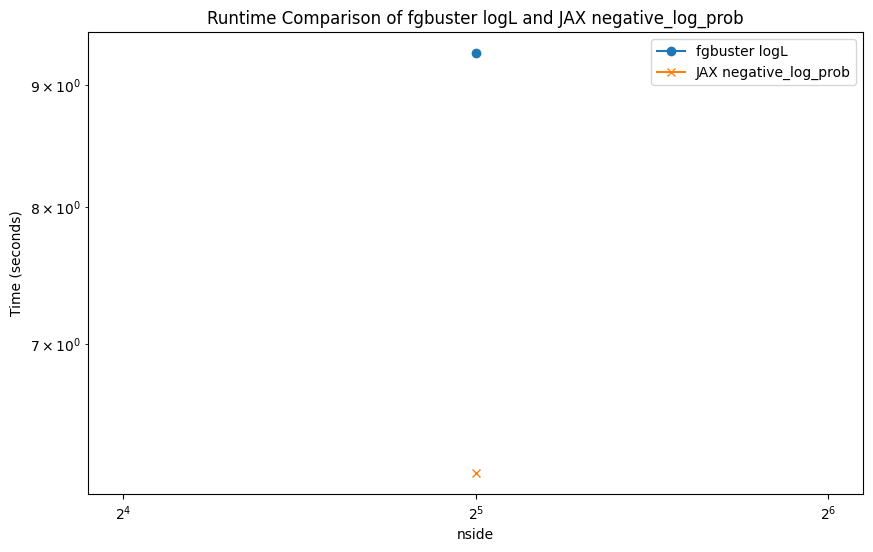

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(nside_values, fgbuster_times, label='fgbuster logL', marker='o')
plt.plot(nside_values, jax_times, label='JAX negative_log_prob', marker='x')
plt.xlabel('nside')
plt.ylabel('Time (ms)')
plt.yscale('log')
plt.xscale('log', base=2)
plt.title('Runtime Comparison of fgbuster logL and JAX negative_log_prob')
plt.legend()
